# Plot Voltages Centered on Dendritic Spikes

This notebook demonstrates how to create voltage plots centered around dendritic spikes (NMDA, Na, Ca) for specific segments.

The plots will show:
- A time window around a randomly selected dendritic spike
- Voltage trace for the segment
- Markers for all spike events within the window
- Soma spike indicators
- Segment descriptions (if available)

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import matplotlib.pyplot as plt

from Modules.post_sim.analysis import load_sim
from Modules.post_sim.voltages.plot_voltage import plot_voltages_centered_on_spikes

## 1. Specify Simulation Directory

Set the path to your simulation directory. Make sure it has already been analyzed (contains `ca.csv`, `nmda.csv`, `na.csv`).

In [2]:
# Replace with your simulation directory
sim_dir = "/home/drfrbc/Neural-Modeling/examples/example_simulations/general_sim"

# Verify directory exists
if not os.path.exists(sim_dir):
    print(f"❌ Directory not found: {sim_dir}")
else:
    print(f"✓ Simulation directory found: {sim_dir}")

✓ Simulation directory found: /home/drfrbc/Neural-Modeling/examples/example_simulations/general_sim


## 2. Load Simulation Data

Load the simulation data including parameters, voltage traces, and segment information.

In [3]:
print("Loading simulation data...")
parameters, sim_data, seg_data, elec_dist = load_sim(sim_dir)

print(f"✓ Loaded simulation data")
print(f"  Voltage shape: {sim_data['v'].shape}")
print(f"  Number of segments: {len(seg_data)}")
print(f"  Time step (dt): {parameters.h_dt} ms")
print(f"  Duration: {parameters.h_tstop} ms")

Loading simulation data...
Loading data from /home/drfrbc/Neural-Modeling/examples/example_simulations/general_sim


--No graphics will be displayed.


✓ Loaded simulation data
  Voltage shape: (300001, 2630)
  Number of segments: 2630
  Time step (dt): 0.1 ms
  Duration: 30000 ms


## 3. Load Dendritic Spike Data

Load the CSV files containing detected dendritic spikes (NMDA, Na, Ca).

In [4]:
# Load dendritic spike CSVs
dendritic_dfs = {}
spike_types = ['nmda', 'na', 'ca']

for spike_type in spike_types:
    csv_path = os.path.join(sim_dir, f"{spike_type}.csv")
    if os.path.exists(csv_path):
        dendritic_dfs[spike_type] = pd.read_csv(csv_path)
        # Count spikes
        df = dendritic_dfs[spike_type]
        n_spikes = df[f"{spike_type}_lower_bound"].notna().sum()
        print(f"✓ Loaded {spike_type.upper():5s}: {n_spikes:5d} spikes detected")
    else:
        print(f"⚠️  {spike_type.upper()} data not found: {csv_path}")

if not dendritic_dfs:
    print("\n❌ No dendritic spike data found. Run find_events_ben.py first!")

✓ Loaded NMDA : 156084 spikes detected
✓ Loaded NA   : 242748 spikes detected
✓ Loaded CA   : 76634 spikes detected


## 4. Select Segments to Plot

Choose which segments you want to plot. You can use:
- Soma: segment 0
- Specific apical segments (e.g., 1647, 1554, 1547)
- Custom segment IDs

In [5]:
# Example: Select soma + some interesting apical segments
seg_ids = [
    0,     # Soma
    1647,  # Sometimes most Ca spikes
    1554,  # Used in Ben's nexus elec_distance calc
    1547,  # Used in nexus elec_distance calc
    1842,  # Right tuft dendrite (halfway)
    1210,  # Oblique (middle, near nexus)
]

print(f"Selected {len(seg_ids)} segments to plot:")
for seg_id in seg_ids:
    seg_info = seg_data[seg_data['segmentID'] == seg_id]
    if not seg_info.empty:
        seg_type = seg_info['Type'].iloc[0]
        print(f"  • Segment {seg_id:4d}: {seg_type}")
    else:
        print(f"  ⚠️  Segment {seg_id} not found in segment data")

Selected 6 segments to plot:
  • Segment    0: soma
  • Segment 1647: apic
  • Segment 1554: apic
  • Segment 1547: apic
  • Segment 1842: apic
  • Segment 1210: apic


## 5. (Optional) Define Segment Descriptions

Add custom descriptions to your segments for better plot titles.

In [6]:
# Optional: Add descriptions for segments
seg_descriptions = {
    1647: "[sometimes most Ca spikes]",
    1554: "[used in Ben's nexus elec_distance calc]",
    1547: "[used in nexus elec_distance calc]",
    1842: "[right tuft dendrite (halfway)]",
    1210: "[oblique (middle, near nexus)]",
    1080: "[apical trunk (very near soma)]",
}

print("Segment descriptions configured.")

Segment descriptions configured.


## 6. Generate Spike-Centered Plots

Create voltage plots centered on randomly selected dendritic spikes. This will generate:
- `output_dir/NMDA/seg_*.png` - NMDA spike-centered plots
- `output_dir/NA/seg_*.png` - Na spike-centered plots  
- `output_dir/CA/seg_*.png` - Ca spike-centered plots

In [7]:
# Create output directory
output_dir = os.path.join(sim_dir, "voltages_spike_centered_example")
os.makedirs(output_dir, exist_ok=True)

print(f"Generating spike-centered plots...")
print(f"Output directory: {output_dir}")
print()

# Generate plots
plot_voltages_centered_on_spikes(
    sim_data=sim_data,
    seg_ids=seg_ids,
    dendritic_dfs=dendritic_dfs,
    output_dir=output_dir,
    window_ms=200,              # 200ms window (±100ms from spike)
    dt=parameters.h_dt,          # Time step from parameters
    show=False,                  # Set True to display plots interactively
    seed=42,                     # Random seed for reproducible spike selection
    seg_descriptions=seg_descriptions  # Optional segment descriptions
)

print("\n✓ Plots generated successfully!")
print(f"\nOutput structure:")
print(f"  {output_dir}/")
print(f"    ├── NMDA/")
print(f"    │   ├── seg_0.png")
print(f"    │   ├── seg_1647.png")
print(f"    │   └── ...")
print(f"    ├── NA/")
print(f"    │   └── seg_*.png")
print(f"    └── CA/")
print(f"        └── seg_*.png")

Generating spike-centered plots...
Output directory: /home/drfrbc/Neural-Modeling/examples/example_simulations/general_sim/voltages_spike_centered_example

[plot_voltage.py] Saved NMDA spike-centered plots to /home/drfrbc/Neural-Modeling/examples/example_simulations/general_sim/voltages_spike_centered_example/NMDA
[plot_voltage.py] Saved NA spike-centered plots to /home/drfrbc/Neural-Modeling/examples/example_simulations/general_sim/voltages_spike_centered_example/NA
[plot_voltage.py] Saved CA spike-centered plots to /home/drfrbc/Neural-Modeling/examples/example_simulations/general_sim/voltages_spike_centered_example/CA

✓ Plots generated successfully!

Output structure:
  /home/drfrbc/Neural-Modeling/examples/example_simulations/general_sim/voltages_spike_centered_example/
    ├── NMDA/
    │   ├── seg_0.png
    │   ├── seg_1647.png
    │   └── ...
    ├── NA/
    │   └── seg_*.png
    └── CA/
        └── seg_*.png


## 7. Display Example Plots

Load and display some of the generated plots in the notebook.

Example plots for segment 1547:

NMDA spike-centered plot:


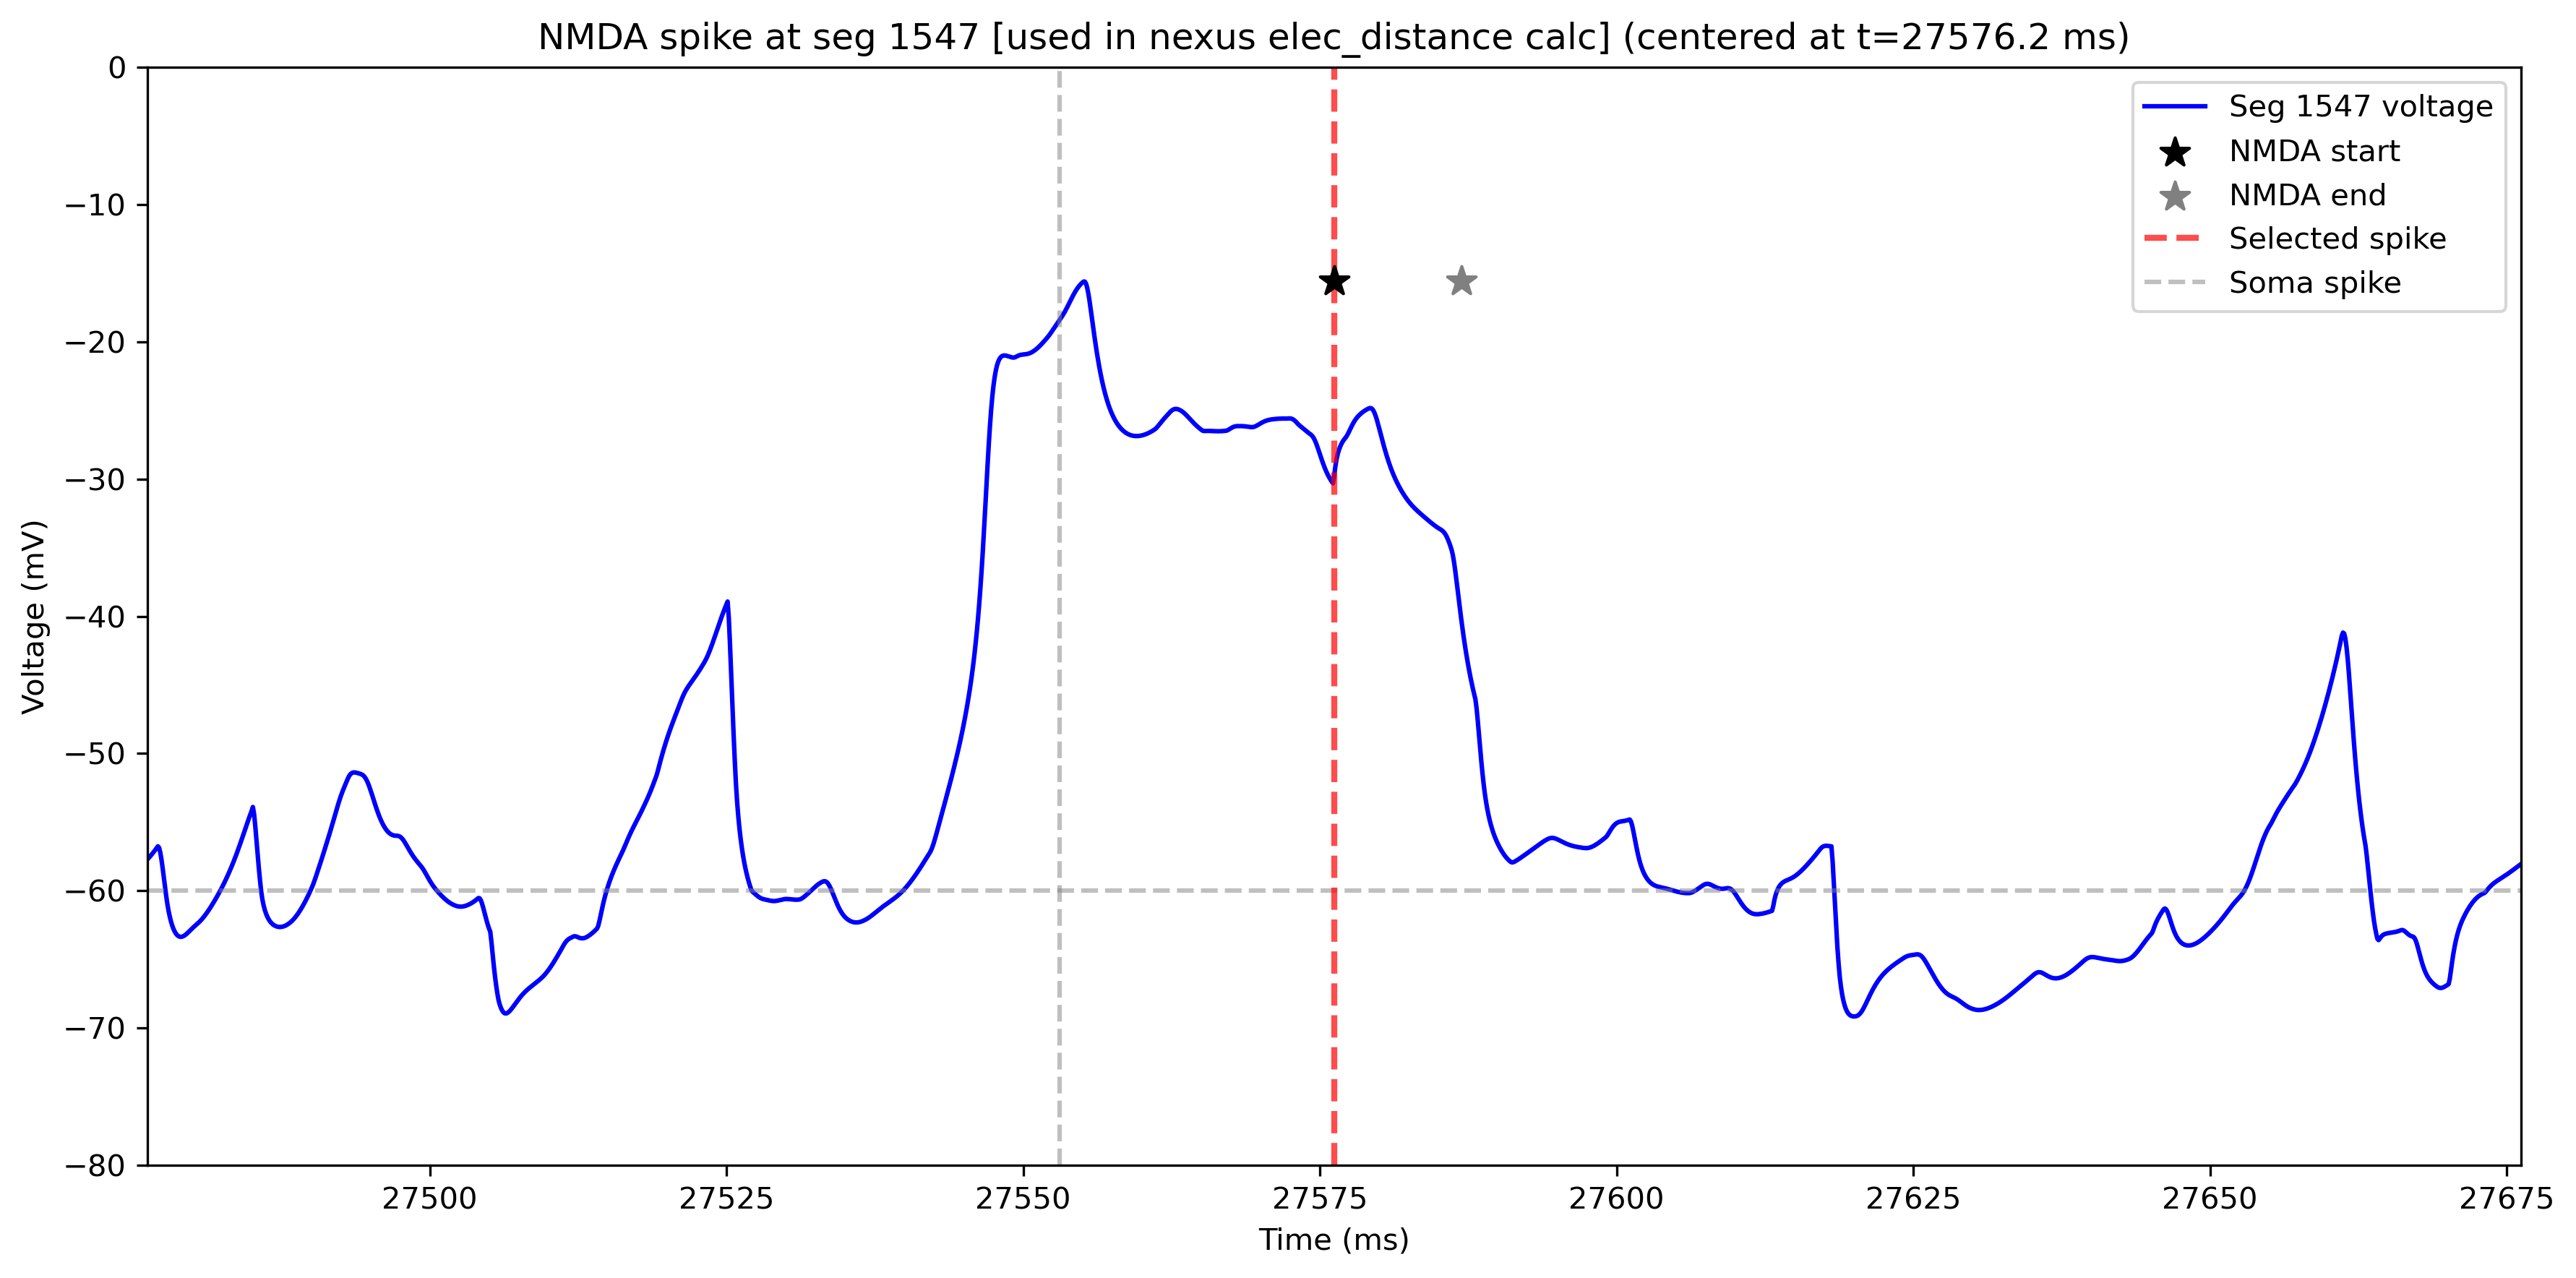


NA spike-centered plot:


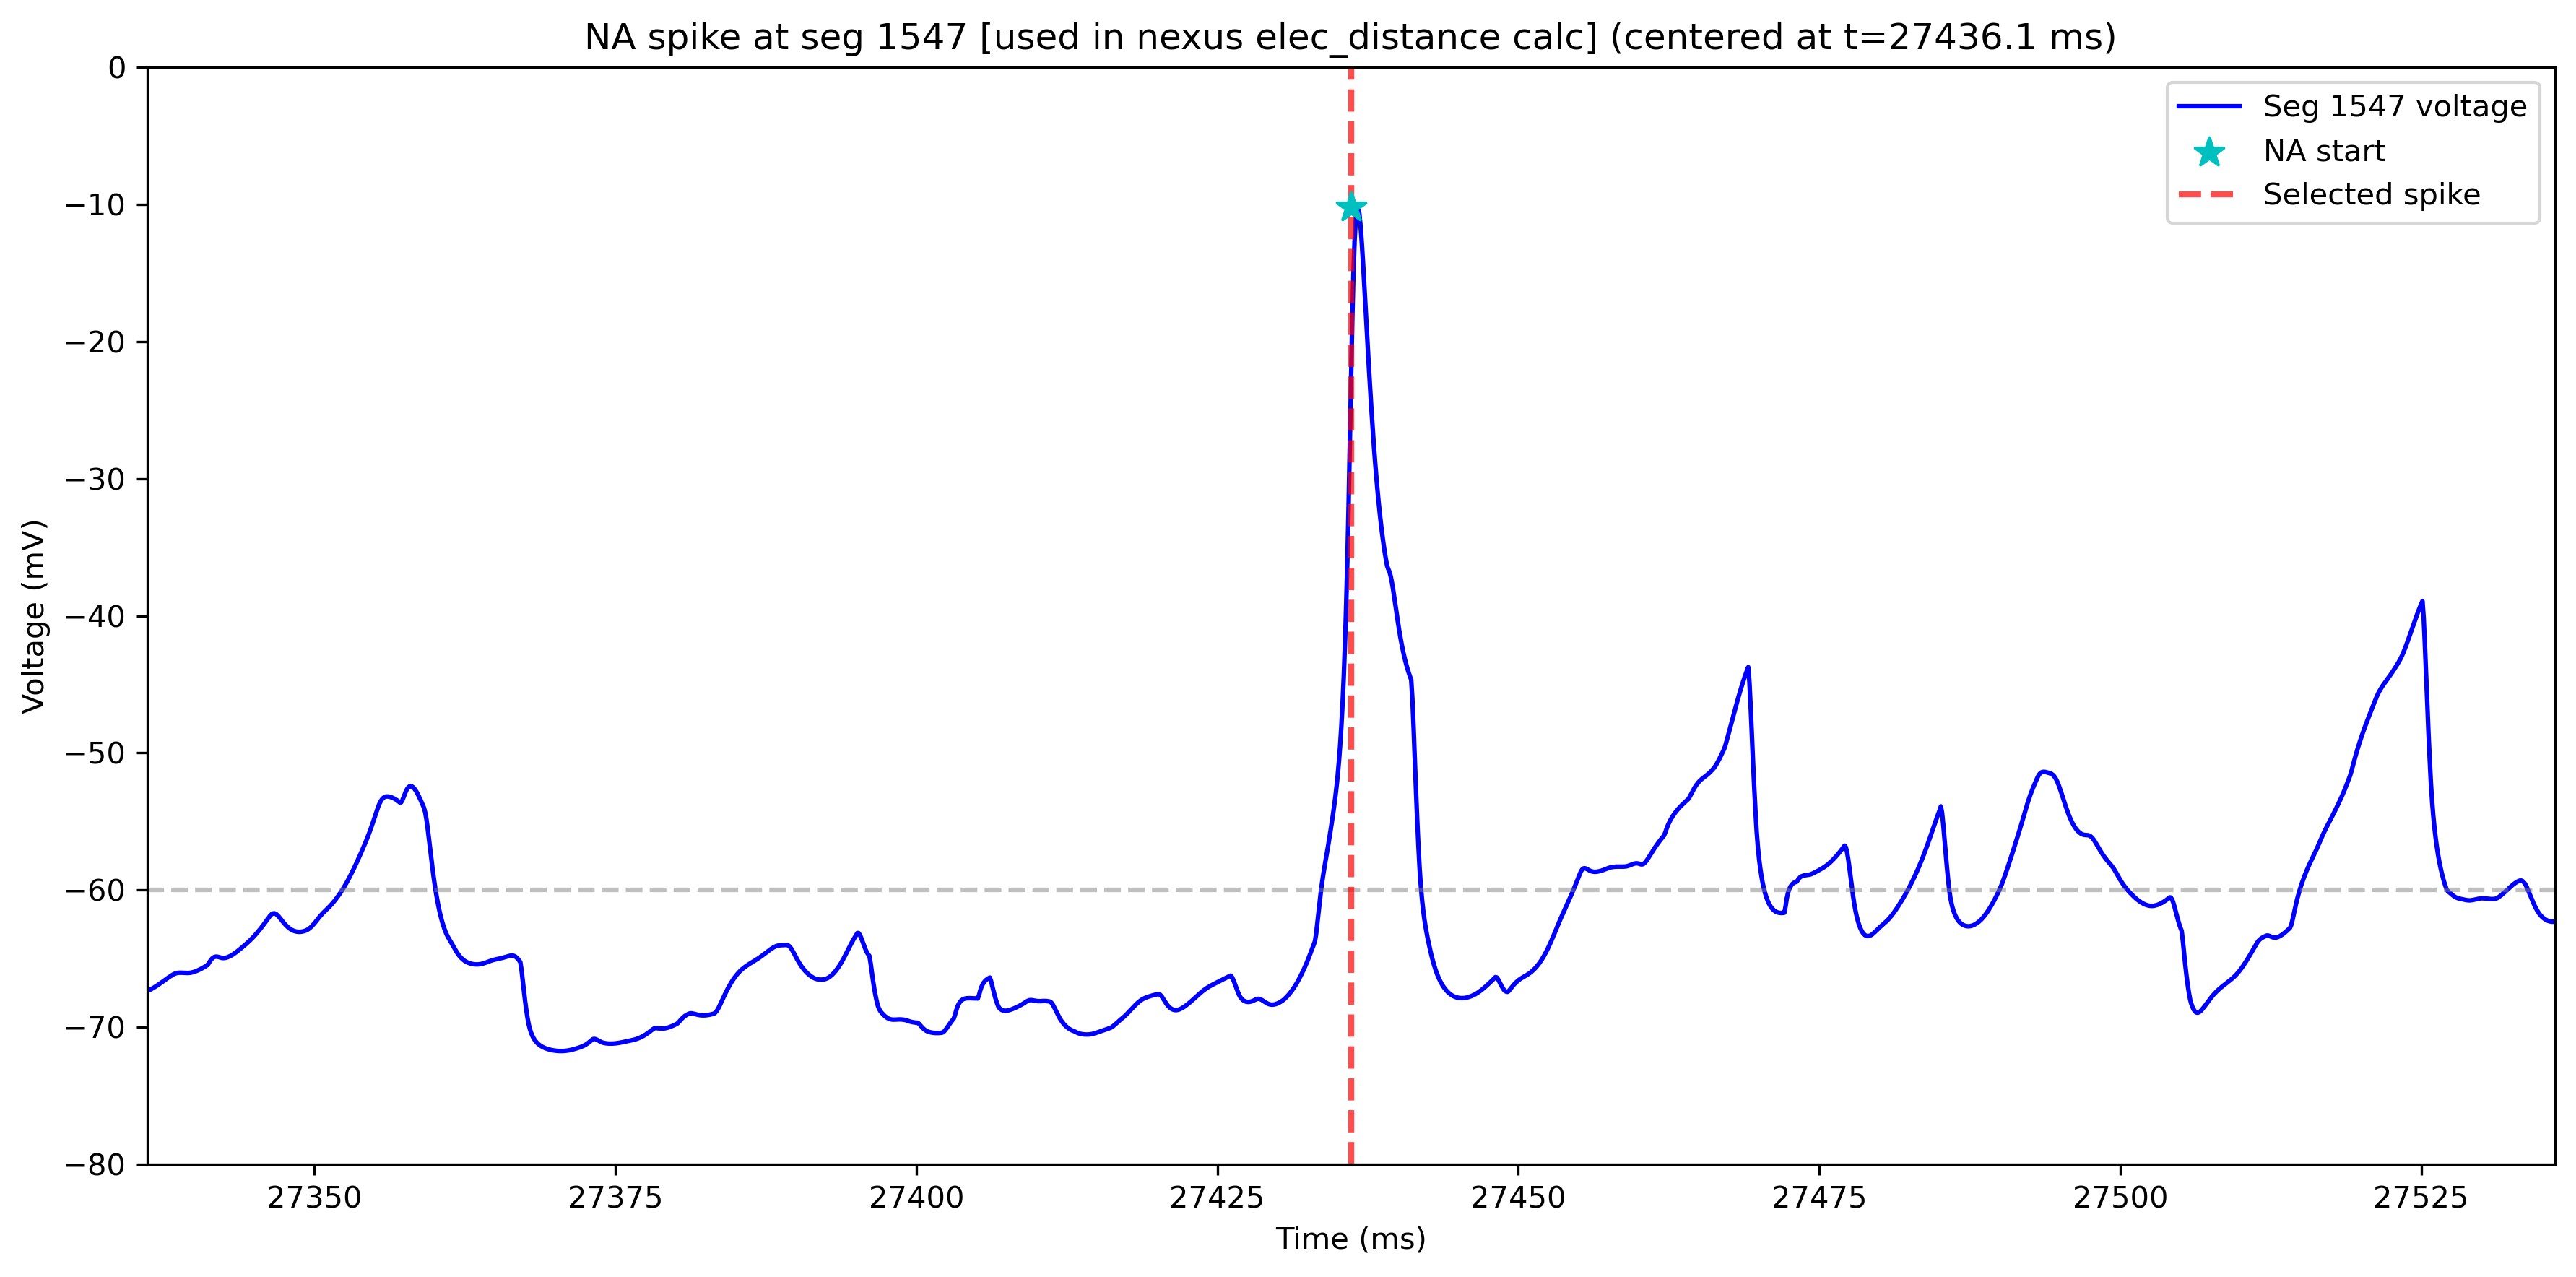


CA spike-centered plot:


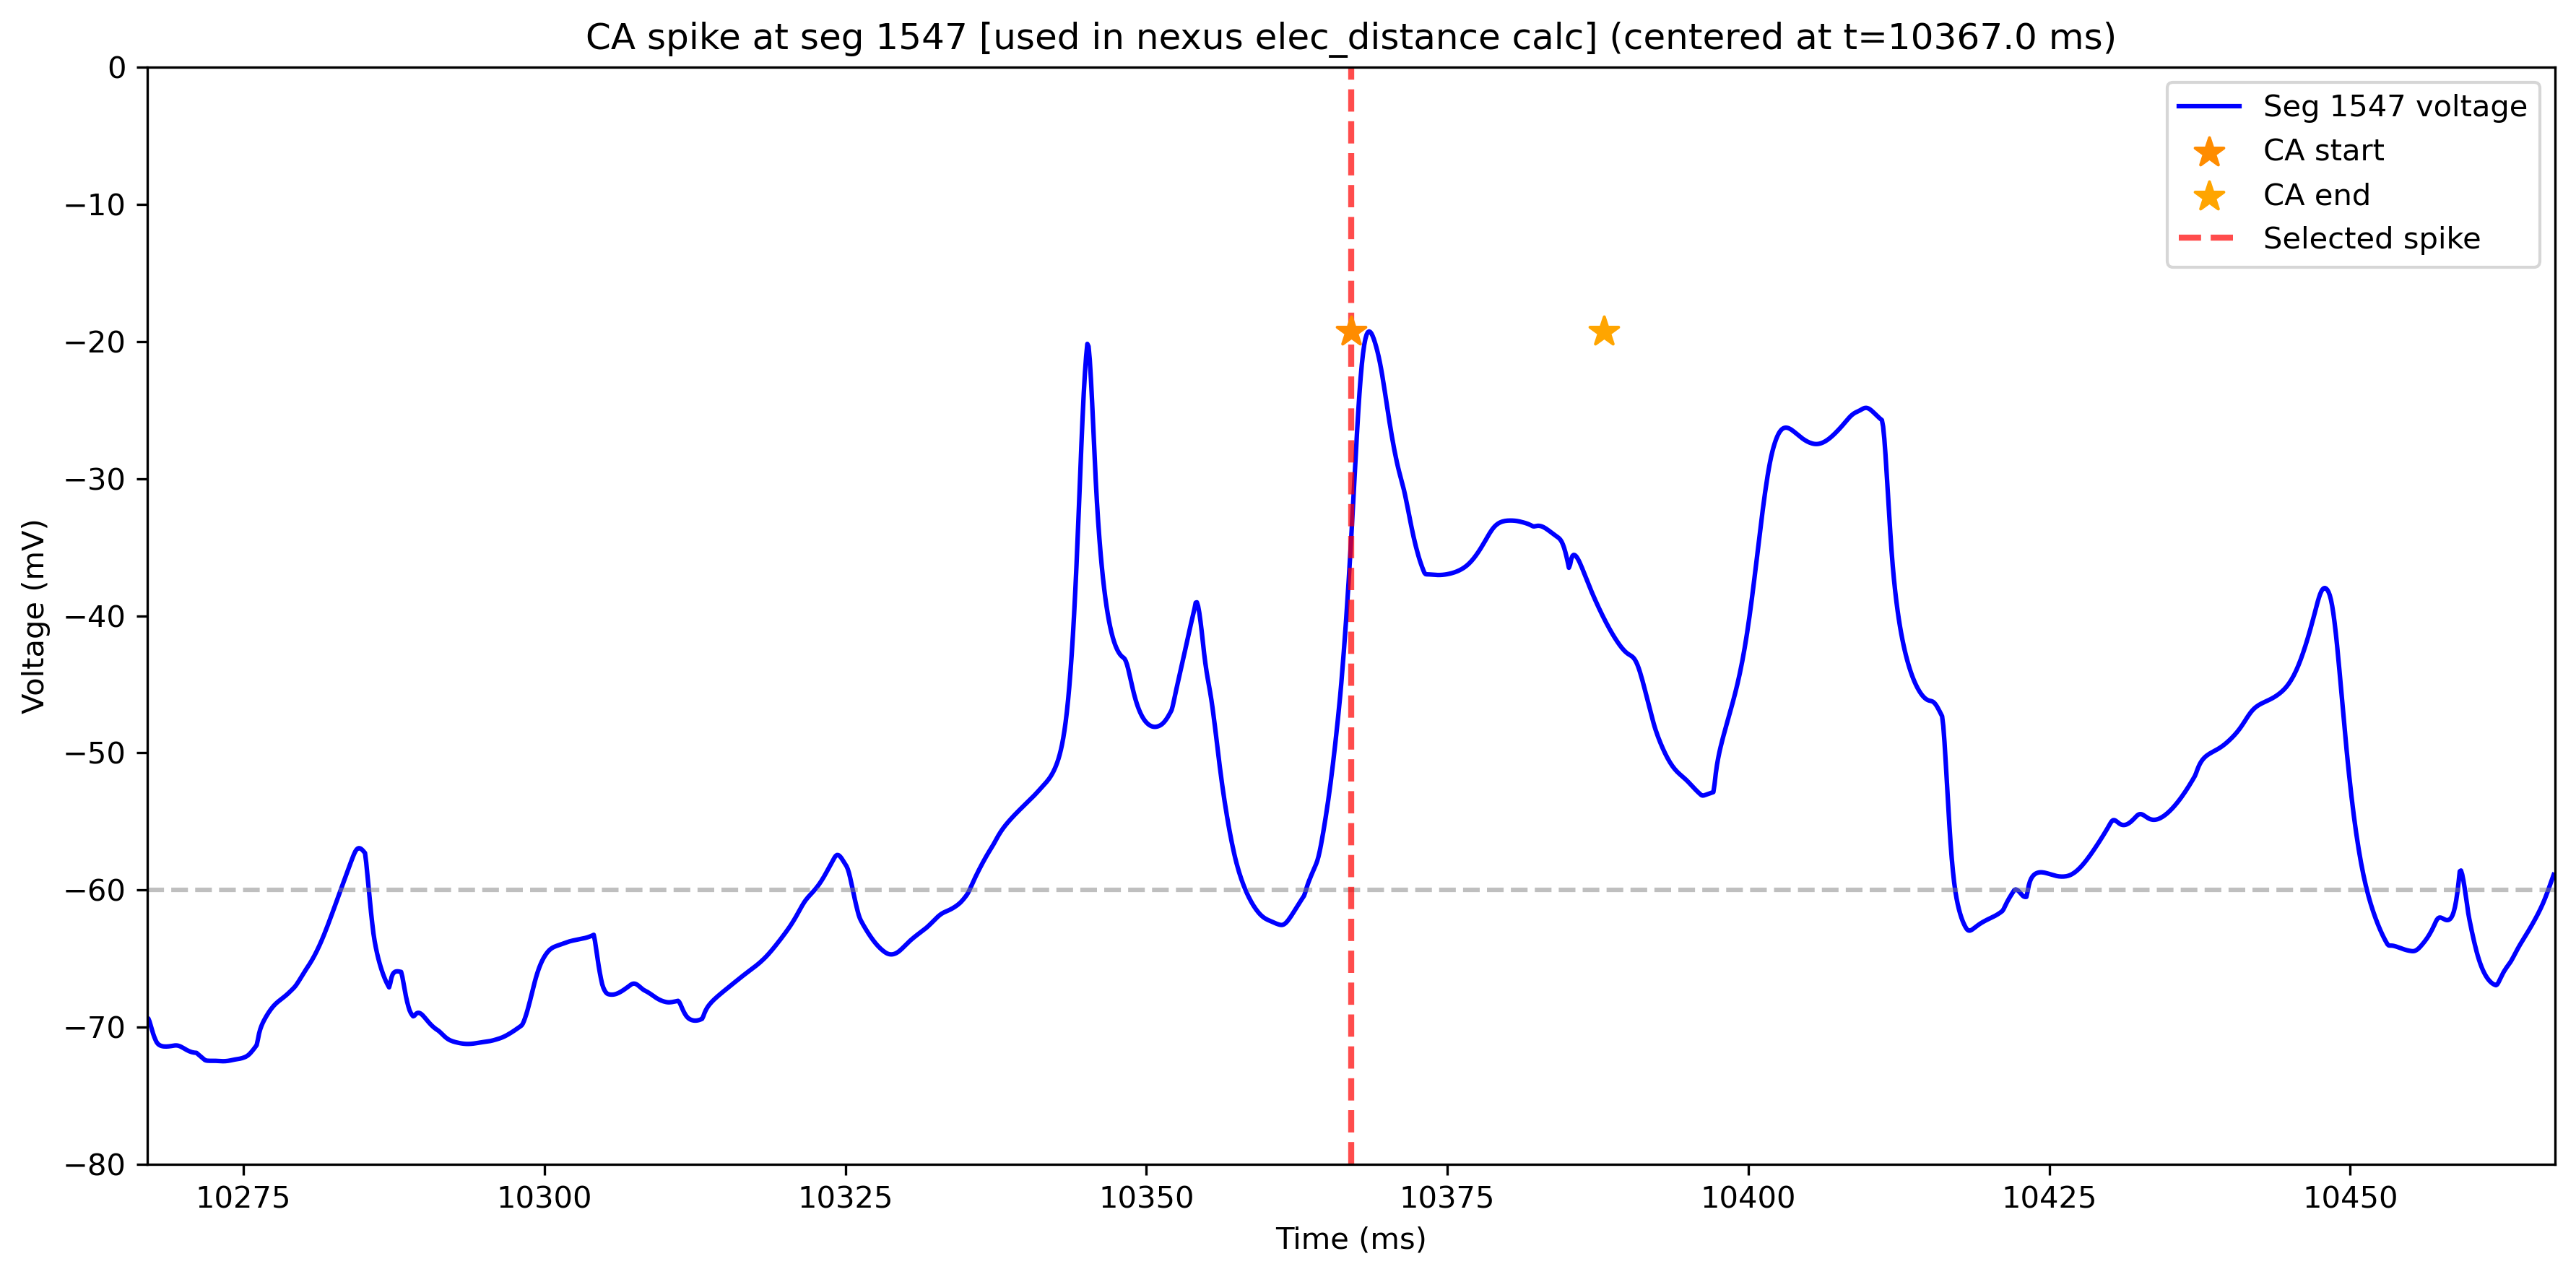

In [8]:
from IPython.display import Image, display

# Display example plots
spike_types_display = ['NMDA', 'NA', 'CA']
example_seg = 1547  # Choose a segment to display

print("Example plots for segment 1547:")
print("="*60)

for spike_type in spike_types_display:
    plot_path = os.path.join(output_dir, spike_type, f"seg_{example_seg}.png")
    
    if os.path.exists(plot_path):
        print(f"\n{spike_type} spike-centered plot:")
        display(Image(filename=plot_path, width=800))
    else:
        print(f"\n⚠️  {spike_type} plot not found: {plot_path}")

## 8. Verify All Generated Files

Check which plots were created for each spike type.

In [9]:
import glob

print("Generated files summary:")
print("="*60)

for spike_type in spike_types_display:
    spike_dir = os.path.join(output_dir, spike_type)
    if os.path.exists(spike_dir):
        files = glob.glob(os.path.join(spike_dir, "seg_*.png"))
        print(f"\n{spike_type} plots: {len(files)} files")
        print(f"  Location: {spike_dir}")
        
        # Show first few filenames
        if files:
            for f in sorted(files)[:5]:
                print(f"    • {os.path.basename(f)}")
            if len(files) > 5:
                print(f"    ... and {len(files) - 5} more")
    else:
        print(f"\n⚠️  {spike_type} directory not found")

Generated files summary:

NMDA plots: 6 files
  Location: /home/drfrbc/Neural-Modeling/examples/example_simulations/general_sim/voltages_spike_centered_example/NMDA
    • seg_0.png
    • seg_1210.png
    • seg_1547.png
    • seg_1554.png
    • seg_1647.png
    ... and 1 more

NA plots: 6 files
  Location: /home/drfrbc/Neural-Modeling/examples/example_simulations/general_sim/voltages_spike_centered_example/NA
    • seg_0.png
    • seg_1210.png
    • seg_1547.png
    • seg_1554.png
    • seg_1647.png
    ... and 1 more

CA plots: 6 files
  Location: /home/drfrbc/Neural-Modeling/examples/example_simulations/general_sim/voltages_spike_centered_example/CA
    • seg_0.png
    • seg_1210.png
    • seg_1547.png
    • seg_1554.png
    • seg_1647.png
    ... and 1 more


## Notes

**Key Features:**
- Each plot is centered on a randomly selected spike for that specific segment
- Time window is adjustable (default: 200ms)
- Shows all spike markers (start/end) within the window
- Includes soma spike indicators (grey dashed lines)
- Displays segment descriptions in titles (if provided)
- Creates "No {spike_type} spikes" plots when no spikes are detected

**Customization Options:**
- `window_ms`: Adjust time window size (e.g., 300ms for wider view)
- `seed`: Change random seed for different spike selection
- `show=True`: Display plots interactively in addition to saving
- `seg_descriptions`: Add custom labels to segment IDs

**Integration with Pipeline:**
This functionality is automatically called in `post_sim_analysis.py` during the standard analysis pipeline, saving plots to `sim_dir/voltages/NMDA/`, `sim_dir/voltages/NA/`, and `sim_dir/voltages/CA/`.